In [1]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
plt.rcParams['font.sans-serif'] = ['SimHei']   # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False      # 解决负号显示问题
data = pd.read_excel('../data/GMV_Month.xlsx')
data.head()

,年月,完成订单GMV,总下单量,商品交易成功率,客单价,完成订单促销率
0,2025-06,1534252.94,376,85.90,4750.01,31.27
1,2025-07,1885914.05,448,87.28,4823.31,29.67
2,2025-08,1629929.39,373,88.74,4924.26,32.33
3,2025-09,1942386.80,441,86.17,5111.54,28.95
4,2025-10,1767754.21,419,84.73,4979.59,31.27


In [2]:
list = data.columns.tolist()
list

['年月', '完成订单GMV', '总下单量', '商品交易成功率', '客单价', '完成订单促销率']

In [3]:
#按列名白名单保留分析所需字段，避免依赖 Excel 中的手工辅助列
keep_cols = ['年月', '完成订单GMV', '总下单量', '商品交易成功率', '客单价', '完成订单促销率']
missing_cols = [c for c in keep_cols if c not in data.columns]
assert not missing_cols, 'GMV_Month.xlsx 缺少必需列：%s' % missing_cols

data = data[keep_cols].sort_values('年月').reset_index(drop=True)
data.head()

,年月,完成订单GMV,总下单量,商品交易成功率,客单价,完成订单促销率
0,2025-06,1534252.94,376,85.90,4750.01,31.27
1,2025-07,1885914.05,448,87.28,4823.31,29.67
2,2025-08,1629929.39,373,88.74,4924.26,32.33
3,2025-09,1942386.80,441,86.17,5111.54,28.95
4,2025-10,1767754.21,419,84.73,4979.59,31.27


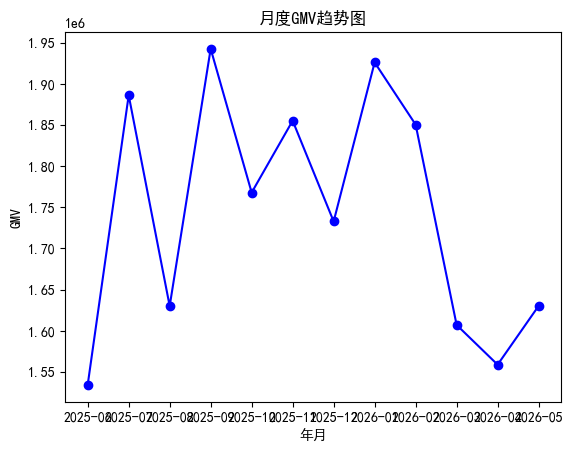

In [4]:
plt.plot(data['年月'],data['完成订单GMV'],'o-b')
plt.xlabel('年月')
plt.ylabel('GMV')
plt.title('月度GMV趋势图')
plt.show()

In [5]:
#假设2026-1到2026-4月GMV下降不显著
df_1_4 = data['完成订单GMV'][(data['年月'] >= '2026-01') & (data['年月'] <= '2026-04')]
mean = data['完成订单GMV'].mean()
t1,p1 = stats.ttest_1samp(df_1_4,mean)
print(f't值为{t1:.4f}-p值为{p1:.4f}')

t值为-0.0874-p值为0.9359


In [6]:
if p1>=0.05:
    print("p值大于0.05,没有足够证据证明2026-01到2026-04GMV下降显著")
else:
    print("p值小于0.05,没有足够证据证明2026-01到2026-04GMV下降不显著")
    

p值大于0.05,没有足够证据证明2026-01到2026-04GMV下降显著


In [7]:
X = data['完成订单促销率']
y = data['完成订单GMV']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                完成订单GMV   R-squared:                       0.045
Model:                            OLS   Adj. R-squared:                 -0.051
Method:                 Least Squares   F-statistic:                    0.4675
Date:                Tue, 06 Oct 2026   Prob (F-statistic):              0.510
Time:                        17:04:11   Log-Likelihood:                -159.07
No. Observations:                  12   AIC:                             322.1
Df Residuals:                      10   BIC:                             323.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.279e+06    6.8e+05      1.882      0.0

In [8]:
if model.f_pvalue >= 0.05:
    print("这个模型不成立,促销率和GMV之间没有统计上显著的关系。")
else:
    print("模型成立,促销率和GMV之间在统计上是显著关系")

这个模型不成立,促销率和GMV之间没有统计上显著的关系。


In [9]:

t1 = data[data['年月'] == '2026-01'].iloc[0]
t2 = data[data['年月'] == '2026-04'].iloc[0]

d_ln_gmv = np.log(t2['完成订单GMV']) - np.log(t1['完成订单GMV'])
d_ln_orders = np.log(t2['总下单量']) - np.log(t1['总下单量'])
d_ln_rate = np.log(t2['商品交易成功率']) - np.log(t1['商品交易成功率'])
d_ln_price = np.log(t2['客单价']) - np.log(t1['客单价'])

print(f"GMV总变化率: {d_ln_gmv:.4f}")
print(f"下单量贡献: {d_ln_orders/d_ln_gmv:.1%}")
print(f"成功率贡献: {d_ln_rate/d_ln_gmv:.1%}")
print(f"客单价贡献: {d_ln_price/d_ln_gmv:.1%}")
print(f"合计: {(d_ln_orders+d_ln_rate+d_ln_price)/d_ln_gmv:.1%}")

GMV总变化率: -0.2115
下单量贡献: 49.6%
成功率贡献: 6.9%
客单价贡献: 43.5%
合计: 100.0%
